# 웨이퍼 이상탐지 & 자동대응 AI Agent

**Digital Factory** — Diffusion 공정 웨이퍼 센서 데이터를 실시간 모니터링하고,  
이상 발생 시 **LangGraph Agent**가 원인 분류 → 대응 조치 → 리포트 생성까지 자동 수행합니다.

> **Colab 실행:** Runtime → *Change runtime type* → **T4 GPU** 권장  
> LLM: HuggingFace **Qwen3-0.6B** (`Qwen/Qwen3-0.6B`)

```
센서 데이터 → detect → [이상?] → classify(Qwen) → action(Qwen) → report
                      ↓ 정상
                   모니터링 계속
```

In [1]:
# 의존성 설치 (Colab — transformers 4.51+ 필수: Qwen3 아키텍처)
!pip install -q "transformers>=4.51.0" torch accelerate \
  langgraph langchain python-dotenv numpy pandas statsmodels matplotlib pydantic

In [2]:
# Colab GPU 확인
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    print(f"✅ GPU: {gpu}")
else:
    print("⚠️ GPU 없음 — CPU로 실행 (Qwen3-0.6B ~1.2GB, 느릴 수 있음)")
    print("   Runtime → Change runtime type → T4 GPU 권장")

⚠️ GPU 없음 — CPU로 실행 (Qwen3-0.6B ~1.2GB, 느릴 수 있음)
   Runtime → Change runtime type → T4 GPU 권장


In [3]:
# Colab Drive 마운트 (선택 — 모델 캐시 저장용)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("로컬 환경 — Drive 마운트 생략")

Mounted at /content/drive


In [4]:
# 환경 설정
import os
from pathlib import Path

LLM_PROVIDER = "qwen"  # @param ["mock", "qwen", "anthropic"]
HF_MODEL_ID = "Qwen/Qwen3-0.6B"
CLAUDE_MODEL = "claude-3-5-haiku-latest"
N_STEPS = 500
Z_SCORE = 1.96
WINDOW_SIZE = 20
REPORT_DIR = Path("reports")

os.environ["LLM_PROVIDER"] = LLM_PROVIDER
os.environ["HF_MODEL_ID"] = HF_MODEL_ID

def _load_secret(name: str) -> str:
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        val = os.getenv(name, "")
        if val:
            return val
        from getpass import getpass
        return getpass(f"{name}: ")

if LLM_PROVIDER == "anthropic":
    os.environ["ANTHROPIC_API_KEY"] = _load_secret("ANTHROPIC_API_KEY")
elif LLM_PROVIDER == "qwen":
    # Qwen3-0.6B는 공개 모델 — HF_TOKEN 선택 (gated model용)
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
        if hf_token:
            os.environ["HF_TOKEN"] = hf_token
    except Exception:
        if os.getenv("HF_TOKEN"):
            pass  # already set

REPORT_DIR.mkdir(exist_ok=True)
print("LLM_PROVIDER:", LLM_PROVIDER)
if LLM_PROVIDER == "qwen":
    print("HF_MODEL_ID:", HF_MODEL_ID)

LLM_PROVIDER: qwen
HF_MODEL_ID: Qwen/Qwen3-0.6B


In [5]:
# Qwen3-0.6B 로드 (HuggingFace)
import json
import re
from types import SimpleNamespace
from typing import Any, Type

from pydantic import BaseModel

_qwen_model = None
_qwen_tokenizer = None


def load_qwen_model(model_id: str | None = None):
    global _qwen_model, _qwen_tokenizer
    if _qwen_model is not None:
        return _qwen_model, _qwen_tokenizer
    if os.environ.get("LLM_PROVIDER") != "qwen":
        return None, None

    from transformers import AutoModelForCausalLM, AutoTokenizer

    model_id = model_id or os.environ.get("HF_MODEL_ID", HF_MODEL_ID)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32

    print(f"[Qwen] loading {model_id} on {device} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if device == "cuda":
        model = AutoModelForCausalLM.from_pretrained(
            model_id, torch_dtype=dtype, device_map="auto", trust_remote_code=True
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_id, torch_dtype=dtype, trust_remote_code=True
        ).to(device)
    model.eval()
    _qwen_model, _qwen_tokenizer = model, tokenizer
    print(f"[Qwen] ready ({sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params)")
    return model, tokenizer


def _generate_qwen(system: str, user: str, max_new_tokens: int = 384) -> str:
    model, tokenizer = load_qwen_model()
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    try:
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except TypeError:
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def _extract_json(text: str) -> dict:
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    start, end = text.find("{"), text.rfind("}")
    if start >= 0 and end > start:
        return json.loads(text[start:end + 1])
    raise ValueError(f"No JSON: {text[:200]}")


def invoke_structured(system: str, user: str, schema: Type[BaseModel]) -> dict | None:
    if os.environ.get("LLM_PROVIDER") == "mock":
        return None
    if os.environ.get("LLM_PROVIDER") == "anthropic":
        from langchain_anthropic import ChatAnthropic
        llm = ChatAnthropic(model=CLAUDE_MODEL, temperature=0.2)
        try:
            out = llm.with_structured_output(schema).invoke(f"{system}\n\n{user}")
            return out.model_dump() if hasattr(out, "model_dump") else dict(out)
        except Exception:
            return None
    if os.environ.get("LLM_PROVIDER") == "qwen":
        fields = ", ".join(schema.model_fields.keys())
        try:
            raw = _generate_qwen(system, user + f"\n\nJSON만 출력. 필드: {fields}")
            return schema.model_validate(_extract_json(raw)).model_dump()
        except Exception as e:
            print(f"  [Qwen] parse fallback: {e}")
            return None
    return None


if LLM_PROVIDER == "qwen":
    load_qwen_model()
else:
    print(f"LLM_PROVIDER={LLM_PROVIDER} — Qwen 로드 생략")

[Qwen] loading Qwen/Qwen3-0.6B on cpu ...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[Qwen] ready (596.0M params)


## Step 1. 웨이퍼 센서 데이터 시뮬레이터

- 정상: ARMA(1,1) 시계열
- 이상: **SPIKE**(장비), **DRIFT**(공정), **LOSS**(센서) 3~5구간 주입

In [6]:
import random
from typing import Literal

import numpy as np
import pandas as pd
from statsmodels.tsa.arima_process import ArmaProcess

AnomalyType = Literal["SPIKE", "DRIFT", "LOSS", "NORMAL"]
ARMA_AR = np.array([1.0, -0.6])
ARMA_MA = np.array([1.0, 0.4])
BASE_SCALE = 100.0


def _generate_normal_series(n_steps: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    process = ArmaProcess(ar=ARMA_AR, ma=ARMA_MA)
    raw = process.generate_sample(nsample=n_steps, scale=1.0, burnin=100)
    return BASE_SCALE + raw + rng.normal(0, 0.5, n_steps)


def _inject_spike(values, start, rng):
    length = rng.integers(1, 4)
    magnitude = rng.uniform(8, 15)
    for i in range(start, min(start + length, len(values))):
        values[i] += magnitude * (1 if rng.random() > 0.3 else -1)


def _inject_drift(values, start, rng):
    length = rng.integers(20, 41)
    step = rng.uniform(0.15, 0.35) * (1 if rng.random() > 0.5 else -1)
    for i in range(start, min(start + length, len(values))):
        values[i] += step * (i - start + 1)


def _inject_loss(values, start, rng):
    length = rng.integers(5, 16)
    for i in range(start, min(start + length, len(values))):
        values[i] = np.nan


def generate_sensor_data(n_steps: int = 500, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    random.seed(seed)
    values = _generate_normal_series(n_steps, seed)
    labels: list[AnomalyType] = ["NORMAL"] * n_steps
    n_anomalies = int(rng.integers(3, 6))
    injectors = [("SPIKE", _inject_spike, 3), ("DRIFT", _inject_drift, 30), ("LOSS", _inject_loss, 10)]
    used_ranges, placed, attempts = [], 0, 0
    while placed < n_anomalies and attempts < 200:
        attempts += 1
        atype, fn, min_span = rng.choice(injectors)
        start = rng.integers(60, max(61, n_steps - min_span - 10))
        end = start + min_span
        if any(not (end < s or start > e) for s, e in used_ranges):
            continue
        fn(values, start, rng)
        for i in range(start, min(start + min_span, n_steps)):
            labels[i] = atype
        used_ranges.append((start, start + min_span))
        placed += 1
    timestamps = pd.date_range("2026-01-01", periods=n_steps, freq="1min")
    return pd.DataFrame({"timestamp": timestamps, "value": values, "ground_truth": labels})


sensor_df = generate_sensor_data(N_STEPS, seed=42)
print(f"생성 완료: {len(sensor_df)} steps, 이상 구간: {(sensor_df['ground_truth'] != 'NORMAL').sum()} points")
sensor_df.head()

생성 완료: 500 steps, 이상 구간: 50 points


,timestamp,value,ground_truth
0,2026-01-01 00:00:00,103.504531,NORMAL
1,2026-01-01 00:01:00,100.968579,NORMAL
2,2026-01-01 00:02:00,101.819501,NORMAL
3,2026-01-01 00:03:00,102.768843,NORMAL
4,2026-01-01 00:04:00,101.528805,NORMAL


## Step 2~4. Tool 정의 (이상탐지 / 원인분류 / 대응액션 / 리포트)

원인 분류·대응 결정은 **Qwen3-0.6B** (또는 mock/anthropic) 사용

In [7]:
from datetime import datetime

from langchain.tools import tool
from pydantic import Field
from statsmodels.tsa.arima.model import ARIMA


def _fit_predict(history: pd.Series):
    clean = history.dropna()
    if len(clean) < 10:
        mean = float(clean.mean()) if len(clean) else 0.0
        std = float(clean.std()) if len(clean) > 1 else 1.0
        return mean, mean + Z_SCORE * std, mean - Z_SCORE * std
    try:
        fitted = ARIMA(clean, order=(1, 0, 1)).fit()
        fc = fitted.get_forecast(steps=1)
        pred = float(fc.predicted_mean.iloc[0])
        ci = fc.conf_int(alpha=0.05)
        return pred, float(ci.iloc[0, 1]), float(ci.iloc[0, 0])
    except Exception:
        mean = float(clean.mean())
        std = float(clean.std()) if clean.std() > 0 else 1.0
        return mean, mean + Z_SCORE * std, mean - Z_SCORE * std


def run_detection(history: pd.DataFrame, current_row: pd.Series) -> dict:
    predicted, upper, lower = _fit_predict(history["value"])
    actual = current_row["value"]
    is_anomaly = pd.isna(actual) or actual > upper or actual < lower
    return {
        "timestamp": str(current_row["timestamp"]),
        "value": None if pd.isna(actual) else float(actual),
        "predicted": round(predicted, 4),
        "upper_bound": round(upper, 4),
        "lower_bound": round(lower, 4),
        "is_anomaly": is_anomaly,
    }


@tool
def detect_anomaly(sensor_history_json: str, current_point_json: str) -> str:
    """ARMA(1,1) 모델로 현재 센서값의 이상 여부를 판정한다."""
    history = pd.DataFrame(json.loads(sensor_history_json))
    current = pd.Series(json.loads(current_point_json))
    return json.dumps(run_detection(history, current), ensure_ascii=False)


class ClassificationResult(BaseModel):
    anomaly_type: str
    confidence: float
    description: str


def _mock_classify(recent_data: list[dict]) -> dict:
    values = [d.get("value") for d in recent_data]
    n_missing = sum(1 for v in values if v is None or (isinstance(v, float) and v != v))
    if values and (values[-1] is None or (isinstance(values[-1], float) and values[-1] != values[-1])):
        return {"anomaly_type": "LOSS", "confidence": 0.92, "description": "센서값 결측 — 센서 이슈 의심"}
    if n_missing >= 3:
        return {"anomaly_type": "LOSS", "confidence": 0.88, "description": "결측/센서 데이터 손실 패턴"}
    clean = [v for v in values if v is not None and v == v]
    if len(clean) >= 5:
        diffs = [abs(clean[i] - clean[i-1]) for i in range(1, len(clean))]
        if diffs and max(diffs) > 5:
            return {"anomaly_type": "SPIKE", "confidence": 0.85, "description": "급격한 스파이크 — 장비 이슈"}
        slope = (clean[-1] - clean[0]) / len(clean)
        if abs(slope) > 0.3:
            return {"anomaly_type": "DRIFT", "confidence": 0.82, "description": "점진적 드리프트 — 공정 이상"}
    return {"anomaly_type": "SPIKE", "confidence": 0.6, "description": "패턴 불명확 이상치"}


def run_classification(recent_data: list[dict]) -> dict:
    system = ("반도체 웨이퍼 센서 이상 분류 Agent. SPIKE/DRIFT/LOSS 중 하나로 분류.\n"
              "- SPIKE: 급격한 변화(장비) | DRIFT: 점진적 변화(공정) | LOSS: 결측(센서)")
    user = json.dumps(recent_data, ensure_ascii=False)
    result = invoke_structured(system, user, ClassificationResult)
    return result if result else _mock_classify(recent_data)


@tool
def classify_anomaly_cause(recent_data_json: str) -> str:
    """최근 20개 시점 데이터를 LLM으로 분석해 이상 원인을 분류한다."""
    return json.dumps(run_classification(json.loads(recent_data_json)), ensure_ascii=False)


class ActionResult(BaseModel):
    action_level: int = Field(ge=1, le=3)
    action_description: str
    reason: str


def _mock_action(classification: dict) -> dict:
    atype, conf = classification.get("anomaly_type", "SPIKE"), classification.get("confidence", 0.5)
    if atype == "LOSS" and conf >= 0.7:
        return {"action_level": 3, "action_description": "장비 중단 + 웨이퍼 재배치", "reason": "센서 데이터 손실 — 심각"}
    if atype in ("SPIKE", "DRIFT") and conf >= 0.75:
        return {"action_level": 2, "action_description": "로트 격리 + 엔지니어 통보", "reason": f"{atype} 패턴 — 격리 필요"}
    return {"action_level": 1, "action_description": "알람 + 모니터링 강화", "reason": "경미한 이상"}


def run_action_decision(classification: dict) -> dict:
    system = "반도체 Fab 대응 Agent. Level 1(알람)/2(격리)/3(중단) 결정. JSON: action_level, action_description, reason"
    user = json.dumps(classification, ensure_ascii=False)
    result = invoke_structured(system, user, ActionResult)
    return result if result else _mock_action(classification)


@tool
def decide_action(classification_json: str) -> str:
    """원인 분류 결과를 바탕으로 대응 수준(Level 1~3)을 결정한다."""
    return json.dumps(run_action_decision(json.loads(classification_json)), ensure_ascii=False)


def run_report(anomaly: dict, classification: dict, action: dict) -> dict:
    ts = anomaly.get("timestamp", datetime.now().isoformat())
    md = f"""# 웨이퍼 이상탐지 리포트\n\n**발생 시각:** {ts}\n\n## 이상탐지\n- 센서값: {anomaly.get('value')} | 예측: {anomaly.get('predicted')}\n- CI: [{anomaly.get('lower_bound')}, {anomaly.get('upper_bound')}]\n\n## 원인 분류\n- **{classification.get('anomaly_type')}** ({classification.get('confidence', 0):.0%})\n- {classification.get('description')}\n\n## 대응\n- **Level {action.get('action_level')}**: {action.get('action_description')}\n- {action.get('reason')}\n"""
    fname = f"anomaly_report_{str(ts).replace(':', '-').replace(' ', '_')}.md"
    path = REPORT_DIR / fname
    path.write_text(md, encoding="utf-8")
    return {"filename": fname, "filepath": str(path), "report": md}


@tool
def generate_report(anomaly_json: str, classification_json: str, action_json: str) -> str:
    """이상탐지·분류·대응 결과를 Markdown 리포트로 생성한다."""
    return json.dumps(run_report(json.loads(anomaly_json), json.loads(classification_json), json.loads(action_json)), ensure_ascii=False)

print("Tools:", [detect_anomaly.name, classify_anomaly_cause.name, decide_action.name, generate_report.name])
print("LLM:", LLM_PROVIDER)

Tools: ['detect_anomaly', 'classify_anomaly_cause', 'decide_action', 'generate_report']
LLM: qwen


## Step 5. State & LangGraph Agent

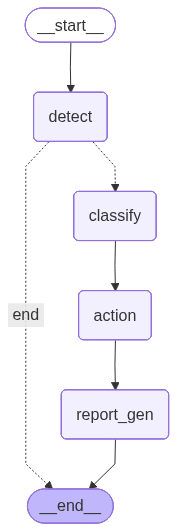

In [8]:
from typing import Literal, TypedDict
from langgraph.graph import END, START, StateGraph


class WaferState(TypedDict, total=False):
    sensor_data: pd.DataFrame
    current_idx: int
    anomaly_result: dict
    classification_result: dict
    action_result: dict
    report: str
    report_meta: dict
    events: list


def detect_node(state: WaferState):
    idx = state["current_idx"]
    df = state["sensor_data"]
    result = run_detection(df.iloc[:idx], df.iloc[idx])
    print(f"  [detect] t={idx} anomaly={result['is_anomaly']}")
    return {"anomaly_result": result}


def classify_node(state: WaferState):
    idx = state["current_idx"]
    df = state["sensor_data"]
    recent = df.iloc[max(0, idx-19):idx+1][["timestamp", "value"]].copy()
    recent["timestamp"] = recent["timestamp"].astype(str)
    recent_list = recent.where(recent.notna(), None).to_dict(orient="records")
    result = run_classification(recent_list)
    print(f"  [classify] {result['anomaly_type']} ({result['confidence']:.0%})")
    return {"classification_result": result}


def action_node(state: WaferState):
    result = run_action_decision(state["classification_result"])
    print(f"  [action] Level {result['action_level']}: {result['action_description']}")
    return {"action_result": result}


def report_node(state: WaferState):
    meta = run_report(state["anomaly_result"], state["classification_result"], state["action_result"])
    events = list(state.get("events", []))
    events.append({"idx": state["current_idx"], "anomaly": state["anomaly_result"],
                   "classification": state["classification_result"], "action": state["action_result"],
                   "report_file": meta["filename"]})
    print(f"  [report] → {meta['filename']}")
    return {"report": meta["report"], "report_meta": meta, "events": events}


def route_after_detect(state: WaferState) -> Literal["classify", "end"]:
    return "classify" if state.get("anomaly_result", {}).get("is_anomaly") else "end"


workflow = StateGraph(WaferState)
workflow.add_node("detect", detect_node)
workflow.add_node("classify", classify_node)
workflow.add_node("action", action_node)
workflow.add_node("report_gen", report_node)
workflow.add_edge(START, "detect")
workflow.add_conditional_edges("detect", route_after_detect, {"classify": "classify", "end": END})
workflow.add_edge("classify", "action")
workflow.add_edge("action", "report_gen")
workflow.add_edge("report_gen", END)

app = workflow.compile()
app

## Step 6. 실행 — 500 step 순차 모니터링

> Qwen 사용 시 이상 1건당 ~5–15초 소요 (GPU 기준). 빠른 테스트는 `LLM_PROVIDER="mock"`

In [9]:
WARMUP = 30
COOLDOWN = 25
events = []
prev_anomaly = False
cooldown_until = -1

print(f"=== 웨이퍼 센서 모니터링 ({len(sensor_df)} steps) | LLM={LLM_PROVIDER} ===\n")
for idx in range(WARMUP, len(sensor_df)):
    detection = run_detection(sensor_df.iloc[:idx], sensor_df.iloc[idx])
    is_anomaly = detection["is_anomaly"]

    if is_anomaly and not prev_anomaly and idx >= cooldown_until:
        state = app.invoke({"sensor_data": sensor_df, "current_idx": idx, "events": events})
        events = state.get("events", events)
        cooldown_until = idx + COOLDOWN
        print(f"⚠️  step {idx} | {state['classification_result']['anomaly_type']} "
              f"→ Level {state['action_result']['action_level']}")

    prev_anomaly = is_anomaly

print(f"\n{'='*60}")
print(f"완료: {len(events)}건 | 리포트 → {REPORT_DIR}/")
print(f"{'='*60}")

=== 웨이퍼 센서 모니터링 (500 steps) | LLM=qwen ===

  [detect] t=33 anomaly=True
  [Qwen] parse fallback: Extra data: line 5 column 4 (char 113)
  [classify] SPIKE (60%)
  [action] Level 2: 격리
  [report] → anomaly_report_2026-01-01_00-33-00.md
⚠️  step 33 | SPIKE → Level 2
  [detect] t=61 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 센서의 데이터가 결측치로 인해 급격한 변화가 발생했습니다.
  [report] → anomaly_report_2026-01-01_01-01-00.md
⚠️  step 61 | LOSS → Level 2
  [detect] t=115 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 격리
  [report] → anomaly_report_2026-01-01_01-55-00.md
⚠️  step 115 | LOSS → Level 2
  [detect] t=144 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 센서의 데이터가 결측치로 인해 급격한 변화가 발생했습니다.
  [report] → anomaly_report_2026-01-01_02-24-00.md
⚠️  step 144 | LOSS → Level 2
  [detect] t=176 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 센서 결측치 또는 불규칙한 데이터
  [report] → anomaly_report_2026-01-01_02-56-00.md
⚠️  step 176 | LOSS → Level 2
  [detect] t=235 anomaly=Tru

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

  [detect] t=368 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 격리
  [report] → anomaly_report_2026-01-01_06-08-00.md
⚠️  step 368 | LOSS → Level 2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

  [detect] t=407 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 센서의 데이터가 결측치로 인해 급격한 변화가 발생했습니다.
  [report] → anomaly_report_2026-01-01_06-47-00.md
⚠️  step 407 | LOSS → Level 2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

  [detect] t=434 anomaly=True
  [classify] LOSS (85%)
  [action] Level 2: 격리
  [report] → anomaly_report_2026-01-01_07-14-00.md
⚠️  step 434 | LOSS → Level 2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give


완료: 12건 | 리포트 → reports/


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Qwen 단건 테스트 (분류 + 대응)

In [10]:
test_idx = int(sensor_df[sensor_df["ground_truth"] != "NORMAL"].index[0])
recent = sensor_df.iloc[max(0, test_idx-19):test_idx+1][["timestamp", "value"]].copy()
recent["timestamp"] = recent["timestamp"].astype(str)
recent_list = recent.where(recent.notna(), None).to_dict(orient="records")

print(f"step {test_idx} | GT={sensor_df.iloc[test_idx]['ground_truth']}\n")
cls = run_classification(recent_list)
act = run_action_decision(cls)
print("분류:", json.dumps(cls, ensure_ascii=False, indent=2))
print("대응:", json.dumps(act, ensure_ascii=False, indent=2))

step 334 | GT=LOSS

분류: {
  "anomaly_type": "LOSS",
  "confidence": 0.8,
  "description": "센서 결측치"
}
대응: {
  "action_level": 2,
  "action_description": "격리",
  "reason": "센서 결측치가 발생하여 대응 필요"
}


## 결과 확인 & 시각화

【최근 이상】 step 434
  분류: LOSS (85%)
  대응: Level 2 — 격리


/tmp/ipykernel_1471/2732119294.py:25: UserWarning: Glyph 49468 (\N{HANGUL SYLLABLE SEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1471/2732119294.py:25: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1471/2732119294.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49468 (\N{HANGUL SYLLABLE SEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing f

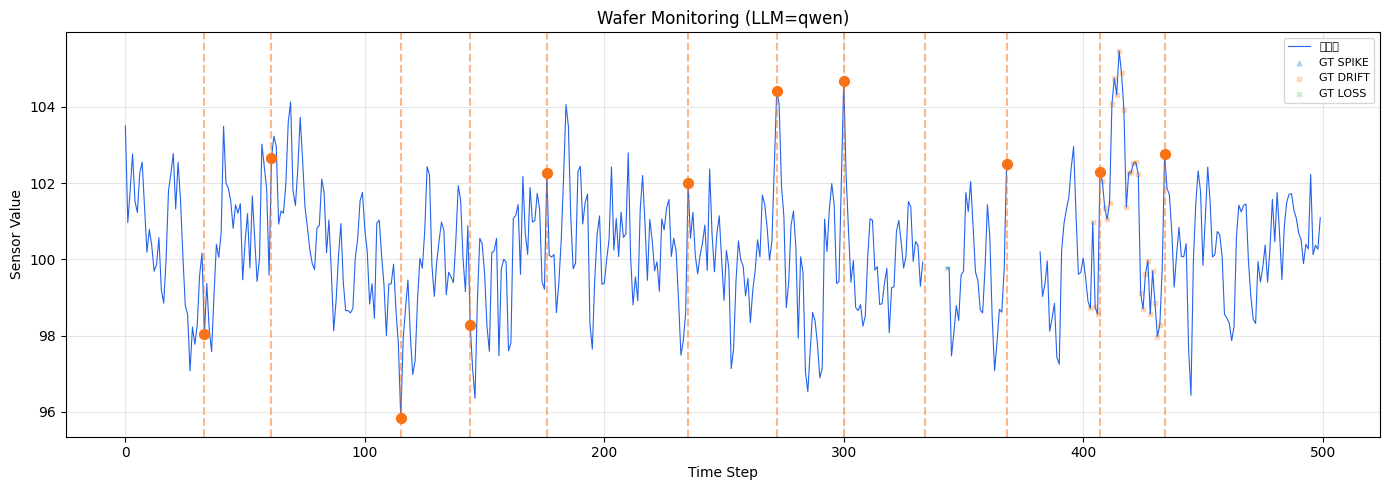

In [11]:
import matplotlib.pyplot as plt

if events:
    last = events[-1]
    print(f"【최근 이상】 step {last['idx']}")
    print(f"  분류: {last['classification']['anomaly_type']} ({last['classification']['confidence']:.0%})")
    print(f"  대응: Level {last['action']['action_level']} — {last['action']['action_description']}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sensor_df.index, sensor_df["value"], color="#2563eb", linewidth=0.8, label="센서값")
colors = {1: "#fbbf24", 2: "#f97316", 3: "#ef4444"}
for ev in events:
    idx, level = ev["idx"], ev["action"].get("action_level", 1)
    ax.axvline(idx, color=colors.get(level, "#ef4444"), alpha=0.5, linestyle="--")
    val = sensor_df.iloc[idx]["value"]
    if not pd.isna(val):
        ax.scatter(idx, val, color=colors.get(level, "#ef4444"), s=50, zorder=5)
for gt, marker in [("SPIKE", "^"), ("DRIFT", "s"), ("LOSS", "x")]:
    mask = sensor_df["ground_truth"] == gt
    ax.scatter(sensor_df.index[mask], sensor_df.loc[mask, "value"],
               marker=marker, s=12, alpha=0.25, label=f"GT {gt}")
ax.set_xlabel("Time Step"); ax.set_ylabel("Sensor Value")
ax.set_title(f"Wafer Monitoring (LLM={LLM_PROVIDER})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()